In [1]:
# df_psmp = pd.read_csv("D:\GitHub\cont_detec\data\processed_placements_results_masked_1.0_0.1_1_0_30000.1.tsv", sep="\t")
# df_psmp_random = pd.read_csv("D:\GitHub\cont_detec\data\processed_placements_results_random_1.0_0.1_1_0_30000.1.tsv", sep="\t")

# df_psmp

# # SPLIT consensus_placement to consensus_placement and consensus_support by splitting on ":"

# df_psmp['consensus_support'] = df_psmp['consensus_placement'].str.split(':').str[1]
# df_psmp['consensus_placement'] = df_psmp['consensus_placement'].str.split(':').str[0]
# df_psmp_random['consensus_support'] = df_psmp_random['consensus_placement'].str.split(':').str[1]
# df_psmp_random['consensus_placement'] = df_psmp_random['consensus_placement'].str.split(':').str[0]

# # same for masked/random_placement
# df_psmp['masked_support'] = df_psmp['masked_placement'].str.split(':').str[1]
# df_psmp['masked_placement'] = df_psmp['masked_placement'].str.split(':').str[0]
# df_psmp_random['random_support'] = df_psmp_random['random_placement'].str.split(':').str[1]
# df_psmp_random['random_placement'] = df_psmp_random['random_placement'].str.split(':').str[0]

# psmp_col = ['sample_name', 'consensus', 'masked', 'random', 'n_masked_cons', 'n_masked_masked',
#        'prop_gen_masked', 'prop_dist_reduced',
#        'consensus_mutations_to_tree', 'masked_mutations_to_tree',
#        'consensus_placement', 'consensus_support', 'masked_placement', 'masked_support',
#        'masked_mutations_masked',
#        'closest_variant', 'n_candidates', 'closeness']

# random_col = ['sample_name', 'consensus', 'masked', 'random', 'n_masked_cons', 'n_masked_masked',
#               'prop_gen_masked', 'prop_dist_reduced',
#               'consensus_mutations_to_tree', 'random_mutations_to_tree',
#               'consensus_placement', 'consensus_support', 'random_placement', 'random_support',
#               'masked_mutations_random',
#               'closest_variant', 'n_candidates', 'closeness']

# # Reorder columns
# df_psmp = df_psmp[psmp_col]
# df_psmp_random = df_psmp_random[random_col]

# df_psmp.shape, df_psmp_random.shape

# # save back

# df_psmp.to_csv("D:\GitHub\cont_detec\data\processed_placements_results_masked_1.0_0.1_1_0_30000.1.tsv", sep="\t", index=False)
# df_psmp_random.to_csv("D:\GitHub\cont_detec\data\processed_placements_results_random_1.0_0.1_1_0_30000.1.tsv", sep="\t", index=False)

In [ ]:
import pandas as pd
import plotly.express as px
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# df_psmp_05 = pd.read_csv("/nfs/research/goldman/anoufa/data/MAPLE_output/processed_placements/processed_placements_results_masked_1_0.05_1_0_30000.1.tsv", sep="\t")
df_psmp_10 = pd.read_csv("/nfs/research/goldman/anoufa/data/MAPLE_output/processed_placements/processed_placements_results_masked_1_0.1_1_0_30000.4.tsv", sep="\t")
# df_psmp_15 = pd.read_csv("/nfs/research/goldman/anoufa/data/MAPLE_output/processed_placements/processed_placements_results_masked_1_0.15_1_0_30000.2.tsv", sep="\t")
# df_psmp_20 = pd.read_csv("/nfs/research/goldman/anoufa/data/MAPLE_output/processed_placements/processed_placements_results_masked_1_0.2_1_0_30000.tsv", sep="\t")
# df_psmp_random_05 = pd.read_csv("/nfs/research/goldman/anoufa/data/MAPLE_output/processed_placements/processed_placements_results_random_1_0.05_1_0_30000.1.tsv", sep="\t")
df_psmp_random_10 = pd.read_csv("/nfs/research/goldman/anoufa/data/MAPLE_output/processed_placements/processed_placements_results_random_1_0.1_1_0_30000.3.tsv", sep="\t")
# df_psmp_random_15 = pd.read_csv("/nfs/research/goldman/anoufa/data/MAPLE_output/processed_placements/processed_placements_results_random_1_0.15_1_0_30000.2.tsv", sep="\t")
# df_psmp_random_20 = pd.read_csv("/nfs/research/goldman/anoufa/data/MAPLE_output/processed_placements/processed_placements_results_random_1_0.2_1_0_30000.tsv", sep="\t")

df_psmp = df_psmp_10
df_psmp_random = df_psmp_random_10

# OR
# df_psmp_random = df_psmp.copy()

df_psmp.shape, df_psmp_random.shape
df_psmp['type'] = 'Masked'
df_psmp_random['type'] = 'Random'

df_psmp['dist_diff'] = df_psmp['consensus'] - df_psmp['masked']
df_psmp_random['dist_diff'] = df_psmp_random['consensus'] - df_psmp_random['random']

df_psmp_random['prop_dist_reduced'] = df_psmp_random['dist_diff'] / df_psmp_random['consensus']

df_psmp['masking_ratio'] = df_psmp['prop_dist_reduced'] / df_psmp['prop_gen_masked']
df_psmp_random['masking_ratio'] = df_psmp_random['prop_dist_reduced'] / df_psmp_random['prop_gen_masked']

df_psmp.shape, df_psmp_random.shape


In [4]:
# Plot the evolution of the number of candidates depending on the threshold

labels = ['Masked 5%', 'Masked 10%', 'Masked 15%', 'Masked 20%', 'Random 5%', 'Random 10%', 'Random 15%', 'Random 20%']
n_candidates_list = []

for df in [df_psmp_05, df_psmp_10, df_psmp_15, df_psmp_20, df_psmp_random_05, df_psmp_random_10, df_psmp_random_15, df_psmp_random_20]:
    
    n_candidates = df.shape[0]
    n_candidates_list.append(n_candidates)

# Plot random and masked on side by side bars 
df_plot = pd.DataFrame({'Threshold': ['5%', '10%', '15%', '20%'], 'Masked': n_candidates_list[:4], 'Random': n_candidates_list[4:], 'Difference': [n_candidates_list[i] - n_candidates_list[i+4] for i in range(4)]})
fig = px.bar(df_plot, x='Threshold', y=['Masked', 'Random'],
             barmode='group',
            #  title='Number of candidates depending on the masking threshold',
             color_discrete_map={'Masked':'#3B6FB6', 'Random':'#734595'})
# Add a line for the difference
fig.add_scatter(x=df_plot['Threshold'], y=df_plot['Difference'], mode='lines+markers', name='Difference',
                line=dict(color='black'))

fig.update_layout(width=700, height=600)

# Change font color and size
fig.update_layout(margin=dict(l=40, r=40, t=10, b=40),
                  font=dict(color="#000000", size=14))

# Change axis names
fig.update_xaxes(title_text='Masking threshold (percentage of median coverage)')
fig.update_yaxes(title_text='Number of candidates')

fig.write_html("../figs/thr_candidates.html")


In [ ]:

print(df_psmp_10.shape, df_psmp_random_10.shape)
df_filtered = df_psmp_10.copy()
df_filtered_random = df_psmp_random_10.copy()

# n_candidates filter
n_candidates = 10
df_filtered = df_filtered[df_filtered['n_candidates'] >= n_candidates]
df_filtered_random = df_filtered_random[df_filtered_random['n_candidates'] >= n_candidates]
print(df_filtered.shape, df_filtered_random.shape)

# closeness filter
closeness = 3
df_filtered = df_filtered[df_filtered['closeness'] >= closeness]
df_filtered_random = df_filtered_random[df_filtered_random['closeness'] >= closeness]
print(df_filtered.shape, df_filtered_random.shape)

# closeness_ratio filter
closeness_ratio = 0.8
df_filtered = df_filtered[df_filtered['closeness_ratio'] >= closeness_ratio]
df_filtered_random = df_filtered_random[df_filtered_random['closeness_ratio'] >= closeness_ratio]
print(df_filtered.shape, df_filtered_random.shape)

# masked/random support filter
support = 0.7
df_filtered = df_filtered[df_filtered['masked_support'] >= support]
df_filtered_random = df_filtered_random[df_filtered_random['random_support'] >= support]
print(df_filtered.shape, df_filtered_random.shape)

# n_masked_masked filter
n_masked_masked = 5000
df_filtered = df_filtered[df_filtered['n_masked_masked'] <= n_masked_masked]
df_filtered_random = df_filtered_random[df_filtered_random['n_masked_masked'] <= n_masked_masked]
print(df_filtered.shape, df_filtered_random.shape)

# Check number of heterozygous sites with at least 5% of heterozygous sites and filter
n_het_sites_min = 10
df_filtered = df_filtered[df_filtered['n_het_sites'] >= n_het_sites_min]
df_filtered_random = df_filtered_random[df_filtered_random['n_het_sites'] >= n_het_sites_min]
print(df_filtered.shape, df_filtered_random.shape)


(10949, 20) (6817, 20)
(7868, 20) (5301, 20)
(5215, 20) (3339, 20)
(2780, 20) (2890, 20)
(1278, 20) (1155, 20)
(657, 20) (514, 20)


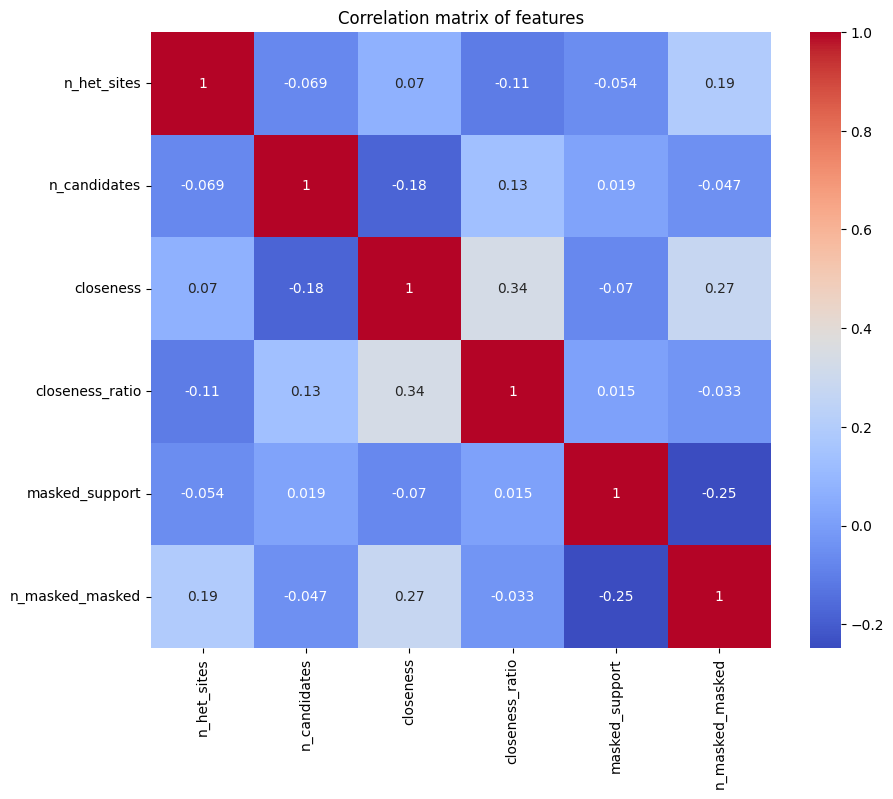

                      PC1       PC2
n_het_sites      0.382725 -0.085728
n_candidates    -0.327903  0.548872
closeness        0.563699  0.252574
closeness_ratio  0.092269  0.792181
masked_support  -0.254944  0.006607
n_masked_masked  0.595596 -0.001676 [0.29835213 0.21170562]


In [98]:

# Try an unsupervised clustering approach to see if we can separate the contaminated from the clean samples


X = df_psmp[['sample_name', 'n_het_sites', 'n_candidates', 'closeness', 'closeness_ratio', 'masked_support', 'n_masked_masked']].copy()
X_random = df_psmp_random[['sample_name', 'n_het_sites', 'n_candidates', 'closeness', 'closeness_ratio', 'random_support', 'n_masked_masked']].copy()


X = X.replace([np.inf, -np.inf], np.nan).dropna()
X_random = X_random.replace([np.inf, -np.inf], np.nan).dropna()

# Take out sample_name cols
sample_names = X['sample_name'].values
sample_names_random = X_random['sample_name'].values
X = X.drop(columns=['sample_name'])
X_random = X_random.drop(columns=['sample_name'])


X_scaled = StandardScaler().fit_transform(X)
X_random_scaled = StandardScaler().fit_transform(X_random)

# PCA that explains 80% of the variance
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_random_pca = pca.fit_transform(X_random_scaled)

# Explain the importance of each of the 9 features in the PCA

# Heatmap of correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(np.corrcoef(X_scaled, rowvar=False), annot=True, xticklabels=X.columns, yticklabels=X.columns, cmap='coolwarm')
plt.title('Correlation matrix of features')
plt.show()

# Feature contributions (loadings) to each PC
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=[col for col in X.columns]
)
print(loadings, pca.explained_variance_ratio_)

In [99]:


df_to_plot = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_to_plot['type'] = 'Masked'
df_to_plot['sample_name'] = sample_names
df_to_plot_random = pd.DataFrame(data=X_random_pca, columns=['PC1', 'PC2'])
df_to_plot_random['type'] = 'Random'
df_to_plot_random['sample_name'] = sample_names_random
df_to_plot = pd.concat([df_to_plot, df_to_plot_random], axis=0)
df_to_plot.shape

# Plot the points on PC1 vs PC2 colored by type
fig = px.scatter(df_to_plot, x='PC1', y='PC2', color='type',
                 title='PCA of samples based on placement statistics',
                 labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'})
fig.show()

# Keep samples with PCA1 > 0 and PCA2 > 1
df_to_plot = df_to_plot[(df_to_plot['PC1'] > 0) & (df_to_plot['PC2'] > 1)]
# count how many masked and random samples are kept
print(df_to_plot['type'].value_counts())

type
Masked    834
Random     81
Name: count, dtype: int64


In [104]:
df_to_plot[df_to_plot['sample_name'] == 'SRR18152477']
df_to_plot[df_to_plot['sample_name'] == 'SRR18207751']

,PC1,PC2,type,sample_name
1411,1.200705,1.378158,Masked,SRR18207751


In [47]:
df_filtered = df_psmp[df_psmp['sample_name'].isin(df_to_plot[df_to_plot['type'] == 'Masked']['sample_name'])]
df_filtered_random = df_psmp_random[df_psmp_random['sample_name'].isin(df_to_plot[df_to_plot['type'] == 'Random']['sample_name'])]

df_filtered.sample(10)

,sample_name,consensus,masked,random,n_masked_cons,n_masked_masked,n_het_sites,prop_gen_masked,prop_dist_reduced,consensus_mutations_to_tree,...,masked_placement,masked_support,masked_mutations_masked,closest_variant,n_candidates,closeness,closeness_ratio,type,dist_diff,masking_ratio
7237,ERR8184053,3.131905,0.0,0.000000,11377.0,23708.0,808.0,0.412367,1.0,C15842T;A24956C,...,ERR8225358,0.053803,G1355K;G8393A;C10449A;G11175K;A11537G;T13195C;...,SRR21328923,17,26,0.787879,Masked,3.131905,2.425026
4730,SRR18068945,4.278767,0.0,2.353915,1962.0,5130.0,139.0,0.105943,1.0,T3049C;G3614A;G4145A;T6294C,...,in2755654,1.000000,C2470T;G6513T;T6514A;T6515A;T6516A;C15240T;C21...,ERR8261911,39,8,1.000000,Masked,4.278767,9.439078
8567,ERR10296094,2.354027,0.0,3.004548,3916.0,9692.0,862.0,0.193158,1.0,C8730T;C29296T,...,ERR9869476,1.000000,G5369R;C8730T;G12160A;G21097S;G22578A;C22674T;...,SRR21695623,85,11,0.733333,Masked,2.354027,5.177112
10021,SRR21145501,2.098306,0.0,2.281405,879.0,3722.0,83.0,0.095074,1.0,C4400A;C29614T,...,SRR21507737,0.499996,C2790T;C4400A;A9424G;G22775A;G22992A;A23013C;T...,SRR21716519,2573,9,0.900000,Masked,2.098306,10.518115
7807,ERR8165664,2.894835,0.0,2.694361,7876.0,18050.0,1185.0,0.340233,1.0,G1772T;G28817T,...,in2276907,0.291061,G1772T;G2632K;C7124T;A11332G;C15720T;C18877T;C...,ERR7609282,2,13,0.764706,Masked,2.894835,2.939159
1419,SRR18207751,7.219998,0.0,8.162043,2309.0,5460.0,167.0,0.105374,1.0,T21988C;G21989C;T21990A;T21991C;T21992A;T21994...,...,in2690169,0.099612,A18163G;T21988C;G21989C;T21990A;T21991C;T21992...,ERR8239939,49,10,1.000000,Masked,7.219998,9.490003
2298,ERR8239329,6.238101,0.0,3.375338,11329.0,21397.0,508.0,0.336689,1.0,T17040C;T24138C;C25614T;T26822C,...,ERR7519039,0.009446,C7851T;C8986T;A11201G;T11515C;A13791M;C16466T;...,ERR7401522,1,10,0.909091,Masked,6.238101,2.970103
9494,ERR5938598,2.157354,0.0,2.975244,2210.0,10022.0,943.0,0.261245,1.0,A21766C;C27889T,...,in3120978,0.043044,T6954C;C14676T;A17615R;G21618C;A21766C;A22995C...,SRR15226072,27,9,0.818182,Masked,2.157354,3.827829
9095,ERR5502202,2.217660,0.0,3.287818,2665.0,11332.0,14900.0,0.289837,1.0,G11071T;C11074T,...,in3134216,0.500000,C913T;T10029C;G11071T;C11074T;C14676T;G24914C;...,SRR15159686,1,12,1.000000,Masked,2.217660,3.450213
8704,ERR7696330,2.304971,0.0,4.092976,4112.0,15680.0,10985.0,0.386851,1.0,C6633T;G14347A,...,in2227036,0.500002,G4181T;T4237C;C6633T;G8561T;C8986T;G9053T;G143...,ERR7104316,5,20,0.909091,Masked,2.304971,2.584976


In [ ]:
# drop random, rename everything that has "masked" by removing "masked"

initial_col = ['sample_name', 'consensus', 'masked', 'random', 'n_masked_cons',
       'n_masked_masked', 'prop_gen_masked', 'prop_dist_reduced',
       'consensus_mutations_to_tree', 'masked_mutations_to_tree',
       'n_het_sites',
       'consensus_placement', 'consensus_support', 'masked_placement',
       'masked_support', 'masked_mutations_masked', 'closest_variant',
       'n_candidates', 'closeness', 'type', 'dist_diff', 'masking_ratio']

df_psmp.drop(columns=['random'], inplace=True)
df_psmp_random.drop(columns=['masked'], inplace=True)


df_psmp.rename(columns={
    'masked': 'distance',
    'n_masked_masked': 'n_masked',
    'masked_mutations_to_tree': 'mutations_to_tree',
    'masked_placement': 'placement',
    'masked_support': 'support',
    'masked_mutations_masked': 'mutations_masked'}, inplace=True)

df_psmp_random.rename(columns={
    'random': 'distance',
    'n_masked_masked': 'n_masked',
    'random_mutations_to_tree': 'mutations_to_tree',
    'random_placement': 'placement',
    'random_support': 'support',
    'masked_mutations_random': 'mutations_masked'}, inplace=True)

In [50]:
# concat both df

df_concat = pd.concat([df_psmp, df_psmp_random], axis=0)

df_concat

,sample_name,consensus,distance,n_masked_cons,n_masked,n_het_sites,prop_gen_masked,prop_dist_reduced,consensus_mutations_to_tree,mutations_to_tree,...,placement,support,mutations_masked,closest_variant,n_candidates,closeness,closeness_ratio,type,dist_diff,masking_ratio
2,ERR13019678,45.287522,2.629985,2342.0,6285.0,59.0,0.131860,0.941927,G974A;C1931A;T2954C;C3604T;C6040T;C11750T;G121...,G974A;C23896T,...,in2541148,0.999936,C19955T;G21618T;G22578A;A22893C;G26529A,SRR22734658,5944,5,1.0,Masked,42.657537,7.143404
7,ERR13049124,42.638775,1.437393,3320.0,8360.0,82.0,0.168545,0.966289,C1931A;T2954C;C11750T;G12160A;C13264T;T14257C;...,C13264T,...,in2541256,0.328987,C2790T;A20055G;G22578A;G22599C;A22893C;T22942A...,SRR22668191,3357,12,0.8,Masked,41.201382,5.733123
9,SRR23381185,42.372373,0.000000,9162.0,21300.0,330.0,0.405912,1.000000,C1931A;T2954C;G12160A;T15240C;C15714T;G16935A;...,NaN,...,in2542698,0.493051,C1931A;C10198T;G12160A;C12880T;C17410T;G21618T...,SRR22864594,21,17,1.0,Masked,42.372373,2.463585
15,ERR13176885,41.264199,2.594484,3171.0,6184.0,97.0,0.100759,0.937125,C1931A;T2954C;C11750T;G12160A;T14257C;T15240C;...,G21793T;C25904T,...,in2543777,0.056882,C2790T;C16338T;G21618T;A22893C;T22942A;G22992A...,SRR22092404,6,9,1.0,Masked,38.669715,9.300648
22,SRR23221981,40.320944,3.610717,2383.0,5242.0,156.0,0.095609,0.910451,T670G;C1931A;C2790T;T2954C;G4184A;C9534T;C1019...,C12459T;A22578G;C22599G,...,in2545637,1.000000,T14257C;A18163G;C22674Y;T22679Y;G22775R;G22992...,SRR23039424,6548,11,1.0,Masked,36.710227,9.522632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5339,ERR6491951,2.243495,0.000000,2930.0,8563.0,57.0,0.188376,1.000000,C2933T;C12171T,NaN,...,in2301855,0.142858,G4181T;C7124T;C8986T;G9053T;G15451A;T27638C;C2...,SRR20593704,518811,13,1.0,Random,2.243495,5.308539
6254,SRR16529718,2.074998,0.000000,13296.0,18874.0,778.0,0.186536,1.000000,C25002T,NaN,...,in2077209,0.333317,C6402T;C19220T;T26767C;C27874T,SRR20593704,561106,4,1.0,Random,2.074998,5.360882
6437,ERR7152704,2.051390,0.000000,14655.0,17692.0,137.0,0.101562,1.000000,G11727T,NaN,...,in2324532,0.038003,A11201G;A11332G;G28916T;G29402T,SRR20593704,567741,4,1.0,Random,2.051390,9.846230
6467,ERR8192251,2.047929,0.000000,13058.0,19994.0,10902.0,0.231950,1.000000,A15303G,NaN,...,ERR7409485,0.053443,C6402T;A11201G;A11332G;C16466T;A23604G,SRR20593704,563976,5,1.0,Random,2.047929,4.311275


In [51]:
df_to_plot = df_concat
df_to_plot['type'] = df_to_plot['type'].replace({'Masked': 'Masked', 'Random': 'Randomly masked'})
df_to_plot.shape, df_to_plot.groupby('type').size()

((959, 22),
 type
 Masked             854
 Randomly masked    105
 dtype: int64)

In [53]:

# N_HET_SITES

fig = px.ecdf(
    df_to_plot,
    x='n_het_sites',
    color='type',
    labels={'n_het_sites': 'Number of Heterozygous Sites'},
    color_discrete_sequence=['#3B6FB6', '#734595']
    # Rename type 'Masked' as 'Alpha' and type 'Random' as 'Beta'
)


fig.update_layout(xaxis_title='Number of Heterozygous Sites', yaxis_title='Cumulative proportion')
# fig.update_traces(line_width=3) 

fig.update_layout(width=700, height=600)

# Change font color and size
fig.update_layout(margin=dict(l=40, r=40, t=10, b=40),
                  font=dict(color="#000000", size=14))


fig.write_html("../figs/n_het_sites_ecdf.html")

# write png
# fig.write_image("../figs/n_het_sites_ecdf.png")
fig

In [54]:
import numpy as np
from scipy.stats import gaussian_kde
import plotly.graph_objects as go

fig = go.Figure()

for t, color in zip(df_to_plot['type'].unique(), ['#3B6FB6', '#734595']):
    data = df_to_plot.loc[df_to_plot['type'] == t, 'n_het_sites']
    #Remove infs and NaNs
    data = data.replace([np.inf, -np.inf], np.nan).dropna()
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 200)
    y_vals = kde(x_vals)
    fig.add_trace(go.Scatter(x=x_vals, y=y_vals, mode='lines', name=t, line=dict(color=color, width=3)))

fig.update_layout(
    xaxis_title='Number of Heterozygous Sites',
    yaxis_title='Probability Density',
    width=700,
    height=600,
    margin=dict(l=40, r=40, t=10, b=40),
    font=dict(color="#000000", size=14)
)

fig.show()


In [56]:

# THRESHOLDS?

df_to_plot['dist_diff'] = df_to_plot['dist_diff'].clip(upper=15)


# Lower clip at 0
df_to_plot['dist_diff'] = df_to_plot['dist_diff'].clip(lower=1)

fig = px.ecdf(
    df_to_plot,
    x='dist_diff',
    color='type',
    labels={'dist_diff': 'Distance Difference'},
    color_discrete_sequence=['#3B6FB6', '#734595']
    # Rename type 'Masked' as 'Alpha' and type 'Random' as 'Beta'
)
fig.update_layout(xaxis_title='Distance difference', yaxis_title='Cumulative proportion')
fig.update_traces(line_width=3) 

fig.update_layout(width=700, height=600)

# Change font color and size
fig.update_layout(margin=dict(l=40, r=40, t=10, b=40),
                  font=dict(color="#000000", size=14))

fig.add_vline(x=2, line_dash='dash', line_color='black', annotation_text='Distance diff = 2', annotation_position='top right')

# Hatch 0 - 10 area
fig.add_shape(
    type="rect",
    x0=0,
    y0=0,
    x1=2,
    y1=1.1,
    fillcolor="rgba(0, 0, 0, 0.1)",
    line=dict(color="rgba(0, 0, 0, 0)"),
)

fig.write_html("../figs/dist_diff_ecdf.html")

# write png
# fig.write_image("../figs/dist_diff_ecdf.png")
fig

In [57]:
fig = px.histogram(
    df_to_plot,
    x='type',
    color='type',
    # labels={'dist_diff': 'Distance Difference'},
    color_discrete_sequence=['#3B6FB6', '#734595']
    # Rename type 'Masked' as 'Alpha' and type 'Random' as 'Beta'
)
fig.update_layout(xaxis_title='Distance difference', yaxis_title='Cumulative proportion')
# fig.update_traces(line_width=3) 

fig.update_layout(width=700, height=600)

# Change font color and size
fig.update_layout(margin=dict(l=40, r=40, t=10, b=40),
                  font=dict(color="#000000", size=14))


fig.write_html("../figs/bar_results.html")

In [62]:

import numpy as np
import plotly.graph_objects as go

# Calculate cumulative counts for each type
bin_edges = np.histogram_bin_edges(df_to_plot['dist_diff'], bins=30)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

hist_data = []
for t in df_to_plot['type'].unique():
    counts, _ = np.histogram(df_to_plot[df_to_plot['type'] == t]['dist_diff'], bins=bin_edges)
    cum_counts = np.cumsum(counts)
    hist_data.append({'type': t, 'cum_counts': cum_counts})

fig = go.Figure()
colors = {'Masked': '#3B6FB6', 'Randomly masked': '#734595'}
for d in hist_data:
    fig.add_trace(go.Scatter(
        x=bin_centers,
        y=d['cum_counts'],
        mode='lines',
        name=d['type'],
        line=dict(color=colors[d['type']], width=3)
    ))

fig.update_layout(
    xaxis_title='Distance difference',
    yaxis_title='Cumulative count',
    width=700,
    height=600,
)
# fig.add_vline(x=2, line_dash='dash', line_color='black', annotation_text='Distance diff = 2', annotation_position='top right')

# Hatch 0 - 2 area (optional)
# fig.add_shape(
#     type="rect",
#     x0=0,
#     y0=0,
#     x1=2,
#     y1=max([max(d['cum_counts']) for d in hist_data]),
#     fillcolor="rgba(0, 0, 0, 0.1)",
#     line=dict(color="rgba(0, 0, 0, 0)")
# )

# Reduce frame size
fig.update_layout(margin=dict(l=40, r=40, t=10, b=40),
                  font=dict(color="#000000", size=14))

fig.write_html("../figs/dist_diff_cumulative_counts_curve.html")
# fig.show()
fig

In [63]:
# PLOT THE ECDF PLOT OF columns masked and random of df_psmp and df_psmp_random


# clip masked up at 10
df_to_plot['distance'] = df_to_plot['distance'].clip(upper=10)

# ECDF of col masked with label type

fig = px.ecdf(
    df_to_plot,
    x='distance',
    color='type',
    labels={'distance': 'Branch length'},
    color_discrete_sequence=['#3B6FB6', '#734595']
)
fig.update_layout(xaxis_title='Branch length', yaxis_title='Cumulative proportion')
fig.update_traces(line_width=3) 

fig.update_layout(width=700, height=600)

# Change font color and size
fig.update_layout(margin=dict(l=40, r=40, t=10, b=40),
                  font=dict(color="#000000", size=14))

# fig.add_vline(x=5, line_dash='dash', line_color='black', annotation_text='Branch length = 5', annotation_position='top right')

# Hatch 0 - 10 area
# fig.add_shape(
#     type="rect",
#     x0=0,
#     y0=0,
#     x1=2,
#     y1=1.1,
#     fillcolor="rgba(0, 0, 0, 0.1)",
#     line=dict(color="rgba(0, 0, 0, 0)"),
# )

fig.write_html("../figs/distance_ecdf.html")
# fig.show()

fig

In [74]:
# ECDF PLOT OF SUPPORT OF PLACEMENTS

df_support_plot = df_to_plot[['consensus_support']]

df_support_plot['type'] = 'Unmasked'

df_support_plot.rename(columns={'consensus_support': 'support'}, inplace=True)

df_support_plot = pd.concat([df_support_plot, df_to_plot[['support', 'type']]], ignore_index=True)

# ECDF plot

fig = px.ecdf(
    df_support_plot,
    x='support',
    color='type',
    # labels={'masked': 'Branch length'},
    color_discrete_sequence=['#18974C', '#3B6FB6', '#734595']
)
fig.update_layout(xaxis_title='Placement support', yaxis_title='Cumulative proportion')
fig.update_traces(line_width=3) 

fig.update_layout(width=700, height=600)

# Change font color and size
fig.update_layout(margin=dict(l=40, r=40, t=10, b=40),
                  font=dict(color="#000000", size=14))

fig.write_html("../figs/support_ecdf.html")
# fig.show()

fig.write_image("../figs/support_ecdf.png")
# fig

C:\Users\oanou\AppData\Local\Temp\ipykernel_11700\1029734114.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\oanou\AppData\Local\Temp\ipykernel_11700\1029734114.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [64]:

# ECDF PLOT OF MASKING RATIO

# clip masking ratio at 20
df_to_plot['masking_ratio'] = df_to_plot['masking_ratio'].clip(upper=20)

fig = px.ecdf(
    df_to_plot,
    x='masking_ratio',
    color='type',
    labels={'masking_ratio': 'Masking Ratio'},
    color_discrete_sequence=['#3B6FB6', '#734595']
)
fig.update_layout(xaxis_title='Masking Ratio', yaxis_title='Cumulative proportion')
fig.update_traces(line_width=3) 

fig.update_layout(width=700, height=600)

# Change font color and size
fig.update_layout(margin=dict(l=40, r=40, t=10, b=40),
                  font=dict(color="#000000", size=14))

fig.write_html("../figs/masking_ratio_ecdf.html")
# fig.show()
fig

In [76]:

# ECDF PLOT closeness

# Upper clip closeness at 30
df_to_plot['closeness'] = df_to_plot['closeness'].clip(upper=30)

fig = px.ecdf(
    df_to_plot,
    x='closeness',
    color='type',
    labels={'closeness': 'Closeness'},
    color_discrete_sequence=['#3B6FB6', '#734595']
)
fig.update_layout(xaxis_title='Closeness', yaxis_title='Cumulative proportion')
fig.update_traces(line_width=3) 

fig.update_layout(width=700, height=600)

# Change font color and size
fig.update_layout(margin=dict(l=40, r=40, t=10, b=40),
                  font=dict(color="#000000", size=14))



fig.write_html("../figs/closeness_ecdf.html")
fig.write_image("../figs/closeness_ecdf.png")
# fig

In [77]:

# BAR PLOT closeness

fig = px.histogram(
    df_to_plot,
    x='closeness',
    color='type',
    barmode='overlay',
    color_discrete_sequence=['#3B6FB6', '#734595'],
    nbins=30,
)


fig.update_layout(xaxis_title='Closeness')
# fig.update_traces(line_width=3) 

fig.update_layout(width=700, height=600)

# Change font color and size
fig.update_layout(margin=dict(l=40, r=40, t=10, b=40),
                  font=dict(color="#000000", size=14))

fig.write_html("../figs/closeness_bar.html")
fig.write_image("../figs/closeness_bar.png")
# fig

In [79]:

# n_candidates ECDF

# clip n_candidates at 500k
df_to_plot['n_candidates'] = df_to_plot['n_candidates'].clip(upper=500000)

fig = px.ecdf(
    df_to_plot,
    x='n_candidates',
    color='type',
    labels={'n_candidates': 'Number of contaminant candidates'},
    color_discrete_sequence=['#3B6FB6', '#734595']
)
fig.update_layout(xaxis_title='Number of contaminant candidates (log scale)', yaxis_title='Cumulative proportion')
fig.update_traces(line_width=3)

fig.update_layout(width=700, height=600)

# Change font color and size
fig.update_layout(margin=dict(l=40, r=40, t=10, b=40),
                  font=dict(color="#000000", size=14))

# x log scale
fig.update_xaxes(type="log")

fig.write_html("../figs/n_candidates_ecdf.html")
fig.show()
fig.write_image("../figs/n_candidates_ecdf.png")

In [ ]:
import df2img
import pandas as pd


In [ ]:
df_path = "D:\GitHub\cont_detec\data\qc_file_SRR21372376.tsv"

df = pd.read_csv(df_path, sep="\t")

# print(df.columns)

df_1 = df[['Ref_pos', 'Ref_nt', 'Cons_pos', 'Cons_nt', 'Masked_cons_nt',
       'Amplicon', 'Primer', 'Mask']]

df_2 = df[['Total_depth', 'Clean_depth',
       'Cons_depth', 'A', 'a', 'C', 'c', 'G', 'g', 'T', 't', 'I', 'i', 'D',
       'd', 'X_A', 'X_a', 'X_C', 'X_c', 'X_G', 'X_g', 'X_T', 'X_t', 'X_I',
       'X_i', 'X_D', 'X_d']]



fig = df2img.plot_dataframe(
    df_1,
    col_width = [0, 2, 2, 2, 2, 4, 6, 4, 2],
    tbl_header={
        "fill_color": "#D0DEBB",
        "font_color": "black",
        "line_width": 2,
        "line_color": "#D0DEBB",
        "font_size": 16,
    },
    tbl_cells={
        "font_color": "black",
        "font_size": 16,
        "line_width": 2,
        "line_color": "#000000",
        "height": 35,
    },
    row_fill_color=("#ffffff", "#D0DEBB"),
    fig_size=(1200, 430),
)

df2img.save_dataframe(fig=fig, filename="../figs/qc_SRR21372376_1.png")


In [ ]:


fig = df2img.plot_dataframe(
    df_2,
    col_width = [0, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    tbl_header={
        "fill_color": "#D0DEBB",
        "font_color": "black",
        "line_width": 2,
        "line_color": "#D0DEBB",
        "font_size": 14,
    },
    tbl_cells={
        "font_color": "black",
        "font_size": 14,
        "line_width": 2,
        "line_color": "#000000",
        "height": 35,
    },
    row_fill_color=("#ffffff", "#D0DEBB"),
    fig_size=(1200, 430),
)

df2img.save_dataframe(fig=fig, filename="../figs/qc_SRR21372376_2.png")

In [ ]:

df_psmp = pd.read_csv("D:\GitHub\cont_detec\data\processed_placements_results_masked_1.0_0.1_1_0_30000.1.tsv", sep="\t")

df_psmp = df_psmp.sample(10)

df_psmp['consensus'] = df_psmp['consensus'].round(2)
df_psmp['masked'] = df_psmp['masked'].round(2)
df_psmp['random'] = df_psmp['random'].round(2)
df_psmp['prop_gen_masked'] = df_psmp['prop_gen_masked'].round(2)
df_psmp['prop_dist_reduced'] = df_psmp['prop_dist_reduced'].round(2)
df_psmp['consensus_support'] = df_psmp['consensus_support'].round(2)
df_psmp['masked_support'] = df_psmp['masked_support'].round(2)

df_psmp.drop(columns=['prop_gen_masked', 'prop_dist_reduced'], inplace=True)

# rename n_masked_cons to n_cons and n_masked_masked to n_masked
df_psmp.rename(columns={'n_masked_cons': 'n_cons', 'n_masked_masked': 'n_masked'}, inplace=True)

df_1 = df_psmp[['sample_name', 'consensus', 'masked', 'random', 'n_cons',
       'n_masked',
       'consensus_mutations_to_tree', 'masked_mutations_to_tree']]

df_2 = df_psmp[['consensus_placement', 'consensus_support', 'masked_placement',
       'masked_support', 'masked_mutations_masked', 'closest_variant', 'n_candidates', 'closeness']]


In [ ]:
fig = df2img.plot_dataframe(
    df_1,
    col_width = [0, 1.5, 1, 1, 1, 1, 1, 4, 3],
    tbl_header={
        "fill_color": "#D0DEBB",
        "font_color": "black",
        "line_width": 2,
        "line_color": "#D0DEBB",
        "font_size": 16,
    },
    tbl_cells={
        "font_color": "black",
        "font_size": 16,
        "line_width": 2,
        "line_color": "#000000",
        "height": 35,
    },
    row_fill_color=("#ffffff", "#D0DEBB"),
    fig_size=(1600, 400),
)

df2img.save_dataframe(fig=fig, filename="../figs/final_df_1.png")


In [ ]:
# rename consensus_support to cons_supp, consensus_placement to cons_plac, same for masked 

df_2.rename(columns={
    'consensus_support': 'cons_supp',
    'consensus_placement': 'cons_plac',
    'masked_support': 'masked_supp',
    'masked_placement': 'masked_plac',
    'n_candidates': 'n_cand',
    'masked_mutations_masked': 'mutations_masked',
}, inplace=True)

fig = df2img.plot_dataframe(
    df_2,
    col_width = [0, 1.5, 1.2, 1.5, 1.3, 7, 1.5, 1, 1],
    tbl_header={
        "fill_color": "#D0DEBB",
        "font_color": "black",
        "line_width": 2,
        "line_color": "#D0DEBB",
        "font_size": 16,
    },
    tbl_cells={
        "font_color": "black",
        "font_size": 16,
        "line_width": 2,
        "line_color": "#000000",
        "height": 35,
    },
    row_fill_color=("#ffffff", "#D0DEBB"),
    fig_size=(1600, 420),
)

df2img.save_dataframe(fig=fig, filename="../figs/final_df_2.png")
